In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import Compose
import cv2
import numpy as np


In [2]:
import torch
import xformers
print(f"Torch version: {torch.__version__}")
print(f"xFormers version: {xformers.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")

Torch version: 2.10.0+cu126
xFormers version: 0.0.35
Is CUDA available: True


In [4]:
import cv2
import torch
import sys

sys.path.insert(0, 'D:/Projects/Minor Project/Depth-Anything-V2/metric_depth')

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

from depth_anything_v2.dpt import DepthAnythingV2

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

encoder = 'vits' # or 'vits', 'vitb'
dataset = 'hypersim' # 'hypersim' for indoor model, 'vkitti' for outdoor model
max_depth = 10 # 20 for indoor model, 80 for outdoor model

check_path = f'D:/Projects/Minor Project/Parameters/DA-Parameter/depth_anything_v2_metric_hypersim_{encoder}.pth'

model = DepthAnythingV2(**model_configs[encoder], max_depth=max_depth)
model.load_state_dict(torch.load(check_path, map_location='cpu'))
model = model.to(DEVICE).eval()

In [ ]:
depth_norm = cv2.normalize(depth, None, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# 2. Apply a colormap (COLORMAP_MAGMA or COLORMAP_INFERNO are popular for depth)
depth_color = cv2.applyColorMap(depth_norm, cv2.COLORMAP_MAGMA)

def resize_to_screen(image, max_width=1280):
    h, w = image.shape[:2]
    if w > max_width:
        ratio = max_width / float(w)
        new_dim = (max_width, int(h * ratio))
        return cv2.resize(image, new_dim, interpolation=cv2.INTER_AREA)
    return image

# Apply it before showing
display_img = resize_to_screen(depth_color)
cv2.imshow('Resized Depth Map', display_img)
cv2.waitKey(0)

In [ ]:
import open3d as o3d

# 1. Download and load a sample RGBD dataset
data = o3d.data.SampleRedwoodRGBDImages()
color_path = data.color_paths[0]
depth_path = data.depth_paths[0]

# 2. Read the images
color_raw = o3d.io.read_image(color_path)
depth_raw = o3d.io.read_image(depth_path)

# 3. Check pixel depth (Redwood is 16-bit unsigned short)
depth_array = np.asarray(depth_raw)
print(f"Depth Image Shape: {depth_array.shape}")
print(f"Data Type: {depth_array.dtype}")
print(f"Example Pixel Value (Depth in mm): {depth_array[240, 320]}")

# 4. Create RGBDImage and visualize
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_raw, convert_rgb_to_intensity=False)

# This should open a window with two images
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.title('Color Image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Depth Image')
plt.imshow(rgbd_image.depth)
plt.show()

In [ ]:
# Assuming 'rgbd_image' is already created from the previous step

# 1. Define Camera Intrinsics 
# (Standard VGA parameters for the Redwood dataset)
pinhole_camera_intrinsic = o3d.camera.PinholeCameraIntrinsic(
    o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

# 2. Create PointCloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image, pinhole_camera_intrinsic)

# 3. Flip it (Open3D uses a right-handed coordinate system where Y is down)
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# 4. Visualize the 3D result
o3d.visualization.draw_geometries([pcd])

In [5]:
import h5py

In [6]:
file_path = 'D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat'

with h5py.File(file_path, 'r') as f:
    images = np.array(f['images'])
    depths = np.array(f['depths'])
    labels = np.array(f['labels'])
    
    # Get class names
    names = []
    for ref in f['names'][0]:
        names.append(''.join(chr(c) for c in f[ref][:].flatten()))
    print(f"Total classes: {len(names)}")
    print(f"Classes: {names[:20]}")  # first 20

Total classes: 894
Classes: ['book', 'bottle', 'cabinet', 'ceiling', 'chair', 'cone', 'counter', 'dishwasher', 'faucet', 'fire extinguisher', 'floor', 'garbage bin', 'microwave', 'paper towel dispenser', 'paper', 'pot', 'refridgerator', 'stove burner', 'table', 'unknown']


In [7]:

# Pick a sample
idx = 30
img_final   = np.transpose(images[idx], (2, 1, 0))   # (480, 640, 3)
depth_final = np.transpose(depths[idx], (1, 0))       # (480, 640)
label_final = np.transpose(labels[idx], (1, 0))       # (480, 640)

print(f"Unique labels in this image: {np.unique(label_final)}")

Unique labels in this image: [  0   2   5  11  19  21  26  32  45  46  49  62  86  87  93 105]


In [8]:
print(img_final.shape)
print(depth_final.shape)

(480, 640, 3)
(480, 640)


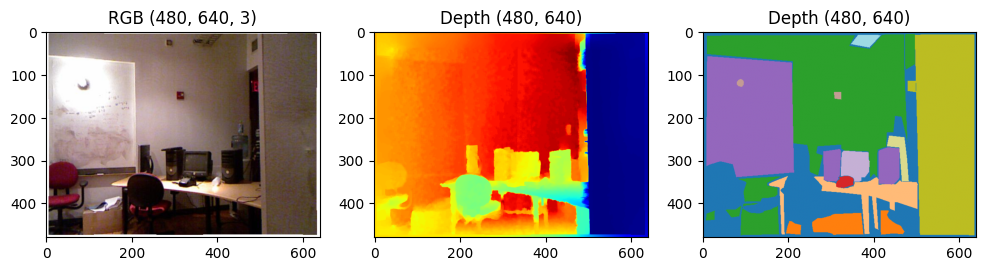

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].imshow(img_final)
ax[0].set_title(f"RGB {img_final.shape}")

ax[1].imshow(depth_final, cmap='jet')
ax[1].set_title(f"Depth {depth_final.shape}")

ax[2].imshow(label_final, cmap='tab20')
ax[2].set_title(f"Depth {depth_final.shape}")

plt.show()

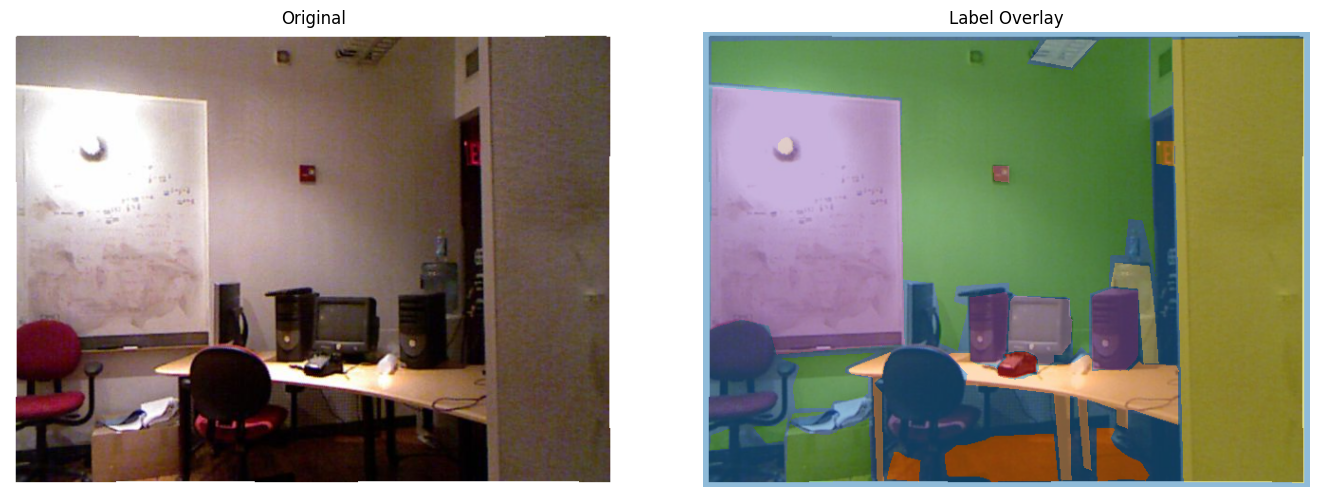

In [10]:
def visualize_label_overlay(img, label, alpha=0.5):
    # Generate random colors for each class
    num_classes = label.max() + 1
    colors = plt.cm.tab20(np.linspace(0, 1, num_classes))
    
    # Create colored label map
    colored_label = colors[label][:, :, :3]  # (480, 640, 3)
    colored_label = (colored_label * 255).astype(np.uint8)
    
    # Overlay
    overlay = (img * (1 - alpha) + colored_label * alpha).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(overlay)
    axes[1].set_title('Label Overlay')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_label_overlay(img_final, label_final)

In [11]:
# test_image_path = cv2.imread('D:/Projects/Minor Project/Datasets/raw/testings_images/nice1.jpg')
# img_final = cv2.cvtColor(test_image_path, cv2.COLOR_BGR2RGB)
depth = model.infer_image(img_final)

In [12]:
print(depth.shape)
print(depth_final.shape)

(480, 640)
(480, 640)


In [13]:
print(depth)
print()
print(depth_final)

[[1.0375414  0.98186195 0.97994345 ... 0.64098215 0.65715337 0.66371316]
 [0.9829092  0.9372125  0.99229985 ... 0.6540813  0.6696957  0.64886117]
 [0.963499   0.93606937 0.97296447 ... 0.63663983 0.6407594  0.63100034]
 ...
 [0.74877703 0.7142659  0.7468814  ... 0.58510536 0.6024657  0.62848765]
 [0.76225036 0.68902576 0.77358234 ... 0.59130454 0.61290383 0.6230938 ]
 [0.80921656 0.8145225  0.78632206 ... 0.62289876 0.6192976  0.65790343]]

[[3.2872226 3.2872736 3.2874014 ... 1.2723136 1.27168   1.2714279]
 [3.287172  3.2872224 3.2873492 ... 1.2720553 1.2714267 1.2711768]
 [3.2870464 3.2870953 3.2872188 ... 1.2714105 1.2707964 1.2705531]
 ...
 [3.1203115 3.1202745 3.1201806 ... 1.1734171 1.1729096 1.1727097]
 [3.120216  3.1201777 3.1200812 ... 1.1739779 1.1734452 1.1732347]
 [3.1201775 3.1201386 3.1200414 ... 1.1742036 1.1736617 1.1734473]]


In [14]:
def align_depth(pred, gt, mask=None):
    """
    Least-squares scale and shift alignment
    pred, gt: [H, W] numpy arrays
    mask: valid pixel mask (optional, exclude 0/invalid GT pixels)
    """
    if mask is None:
        mask = gt > 0  # exclude invalid GT pixels

    pred_valid = pred[mask].flatten()
    gt_valid   = gt[mask].flatten()

    # Solve: gt ≈ scale * pred + shift
    A = np.stack([pred_valid, np.ones_like(pred_valid)], axis=1)  # [N, 2]
    result = np.linalg.lstsq(A, gt_valid, rcond=None)
    scale, shift = result[0]

    pred_aligned = scale * pred + shift
    return pred_aligned, scale, shift

# Align
pred_aligned, scale, shift = align_depth(depth, depth_final)

In [15]:
print(pred_aligned)
print()
print(depth_final)

[[1.9097089 1.8016765 1.7979542 ... 1.1402831 1.1716594 1.184387 ]
 [1.8037086 1.7150453 1.8219287 ... 1.1656988 1.1959946 1.1555704]
 [1.7660478 1.7128273 1.7844132 ... 1.1318579 1.1398509 1.1209158]
 ...
 [1.3494326 1.2824721 1.3457546 ... 1.0318679 1.0655513 1.1160406]
 [1.3755742 1.2334999 1.3975612 ... 1.0438958 1.085804  1.1055751]
 [1.4667006 1.4769955 1.4222795 ... 1.1051967 1.0982096 1.1731147]]

[[3.2872226 3.2872736 3.2874014 ... 1.2723136 1.27168   1.2714279]
 [3.287172  3.2872224 3.2873492 ... 1.2720553 1.2714267 1.2711768]
 [3.2870464 3.2870953 3.2872188 ... 1.2714105 1.2707964 1.2705531]
 ...
 [3.1203115 3.1202745 3.1201806 ... 1.1734171 1.1729096 1.1727097]
 [3.120216  3.1201777 3.1200812 ... 1.1739779 1.1734452 1.1732347]
 [3.1201775 3.1201386 3.1200414 ... 1.1742036 1.1736617 1.1734473]]


Text(0.5, 1.0, 'Scaled depth (480, 640)')

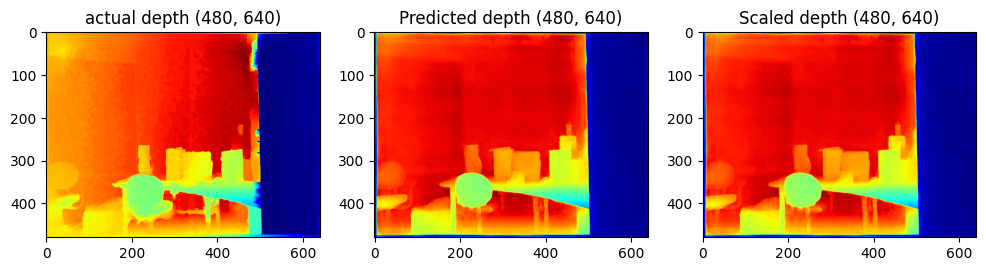

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].imshow(depth_final, cmap='jet')
ax[0].set_title(f"actual depth {depth_final.shape}")

ax[1].imshow(depth, cmap='jet')
ax[1].set_title(f"Predicted depth {depth.shape}")


ax[2].imshow(pred_aligned, cmap='jet')
ax[2].set_title(f"Scaled depth {pred_aligned.shape}")

In [17]:
import open3d as o3d

fx, fy = 518.8579, 519.4696
cx, cy = 325.5824, 253.7362
width, height = 640, 480

# Create the Intrinsic object
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [18]:
# Assuming img_final and depth_final are your processed NumPy arrays
# img_final: (480, 640, 3) uint8
# depth_final: (480, 640) float32 (meters)
# Both should be (480, 640, 3) and (480, 640) respectively.

img_contiguous = np.ascontiguousarray(img_final.astype(np.uint8))
depth_contiguous = np.ascontiguousarray(pred_aligned.astype(np.float32))

# Now Open3D will accept them
color_raw = o3d.geometry.Image(img_contiguous)
depth_raw = o3d.geometry.Image(depth_contiguous)

print(f"Color: {np.asarray(color_raw).shape}")
print(f"Depth: {np.asarray(depth_raw).shape}")

# Create RGBD Image
# depth_trunc=10.0 ignores objects further than 10 meters
# convert_rgb_to_intensity=False keeps the colors for the point cloud
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, 
    depth_raw, 
    depth_scale=1.0,    # 1.0 because NYU is already in meters
    depth_trunc=10.0,   # Increase this if your room is very deep
    convert_rgb_to_intensity=False
)

# Generate Point Cloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image, 
    intrinsic
)

# Flip it: NYU coordinates are often inverted compared to Open3D's visualizer
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Visualize
o3d.visualization.draw_geometries([pcd])

Color: (480, 640, 3)
Depth: (480, 640)


In [ ]:
depth_resized = cv2.resize(depth, (depth_final.shape[1], depth_final.shape[0]))
error = np.abs(depth_resized - depth_final)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].imshow(depth_final, cmap='plasma', vmin=0, vmax=10)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(depth_resized, cmap='plasma', vmin=0, vmax=10)
axes[1].set_title('Predicted')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(error, cmap='Reds')
axes[2].set_title('Absolute Error')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], label='error (meters)')

plt.tight_layout()
plt.show()

In [ ]:
vit_encoder = model.pretrained
print(vit_encoder)

In [ ]:
# test_image_path = cv2.imread('D:/Projects/Minor Project/Datasets/raw/testings_images/nice1.jpg')
# img_final = cv2.cvtColor(test_image_path, cv2.COLOR_BGR2RGB)

In [ ]:
def get_depth_encoder_features(depth_model, raw_img_np):
    features = {}
    input_size = {}

    def hook(module, input, output):
        features['out'] = output

    handle = depth_model.pretrained.blocks[-1].register_forward_hook(hook)

    with torch.no_grad():
        # Get the tensor to know exact H, W after preprocessing
        image, (h, w) = depth_model.image2tensor(raw_img_np, input_size=518)
        input_size['h'] = image.shape[2] // 14  # patch size is 14
        input_size['w'] = image.shape[3] // 14
        depth_model.forward(image.to(DEVICE))

    handle.remove()

    enc = features['out'][:, 1:, :]  # remove CLS token
    B, N, C = enc.shape
    
    pH = input_size['h']  # actual patch height
    pW = input_size['w']  # actual patch width
    
    print(f"Patch grid: {pH}x{pW}={pH*pW}, N={N}")  # should match

    spatial_map = enc.reshape(B, pH, pW, C).permute(0, 3, 1, 2)  # [1, 384, pH, pW]
    return spatial_map

depth_features = get_depth_encoder_features(model, img_final)
print(f"Shape: {depth_features.shape}")  # e.g. [1, 384, 37, 49] for non-square

img_raw shape:  (3, 640, 480)
inst_raw shape: (640, 480)
dep_raw shape:  (640, 480)


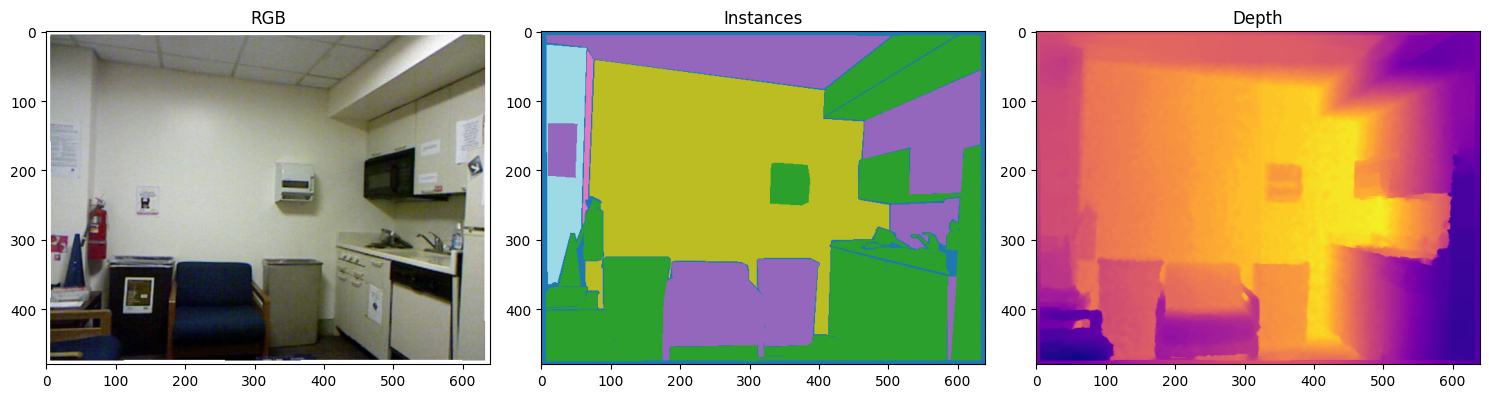

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2

f = h5py.File('D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat', 'r')

# test different transpose combinations
img_raw  = np.array(f['images'][0])    # (3, 640, 480)
inst_raw = np.array(f['instances'][0]) # (640, 480)
dep_raw  = np.array(f['depths'][0])    # (640, 480)

print(f"img_raw shape:  {img_raw.shape}")
print(f"inst_raw shape: {inst_raw.shape}")
print(f"dep_raw shape:  {dep_raw.shape}")

# correct transpose
img  = img_raw.transpose(2, 1, 0)   # (480, 640, 3)
inst = inst_raw.T                    # (480, 640)
dep  = dep_raw.T                     # (480, 640)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img);                      axes[0].set_title('RGB')
axes[1].imshow(inst, cmap='tab20');       axes[1].set_title('Instances')
axes[2].imshow(dep, cmap='plasma');       axes[2].set_title('Depth')
plt.tight_layout()
plt.show()

In [1]:
import h5py
import os
import numpy as np
import matplotlib.pyplot as plt

BASE = r'D:\Projects\Minor Project\Datasets\raw\scene_cam_00_final_hdf5'

# list first few files
files = sorted(os.listdir(BASE))
print(f"Total files: {len(files)}")
print("First 10:", files[:10])

# open one color file and check keys + shape
color_file = os.path.join(BASE, 'frame.0000.color.hdf5')
with h5py.File(color_file, 'r') as f:
    print(f"\nColor file keys: {list(f.keys())}")
    img = np.array(f['dataset'])
    print(f"Image shape: {img.shape}")
    print(f"Image dtype: {img.dtype}")

# check what other file types exist
types = set()
for fname in files:
    parts = fname.split('.')
    if len(parts) >= 3:
        types.add('.'.join(parts[1:-1]))
print(f"\nFile types found: {types}")

Total files: 392
First 10: ['frame.0000.color.hdf5', 'frame.0000.diffuse_illumination.hdf5', 'frame.0000.diffuse_reflectance.hdf5', 'frame.0000.residual.hdf5', 'frame.0001.color.hdf5', 'frame.0001.diffuse_illumination.hdf5', 'frame.0001.diffuse_reflectance.hdf5', 'frame.0001.residual.hdf5', 'frame.0002.color.hdf5', 'frame.0002.diffuse_illumination.hdf5']

Color file keys: ['dataset']
Image shape: (768, 1024, 3)
Image dtype: float16

File types found: {'0037.diffuse_illumination', '0019.diffuse_illumination', '0090.residual', '0019.residual', '0031.residual', '0099.diffuse_illumination', '0068.residual', '0046.residual', '0008.diffuse_reflectance', '0080.diffuse_reflectance', '0026.color', '0003.color', '0018.color', '0062.diffuse_illumination', '0044.residual', '0058.diffuse_reflectance', '0010.diffuse_illumination', '0054.diffuse_reflectance', '0089.residual', '0037.residual', '0029.diffuse_illumination', '0042.residual', '0063.diffuse_reflectance', '0046.color', '0037.color', '0071.r

Keys: ['dataset']
Instance shape: (768, 1024), dtype: int16
Instances: 32
  id=4: coverage=0.002
  id=5: coverage=0.001
  id=6: coverage=0.012
  id=7: coverage=0.002
  id=8: coverage=0.036
  id=9: coverage=0.035
  id=10: coverage=0.037
  id=11: coverage=0.064
  id=12: coverage=0.005
  id=13: coverage=0.000
  id=14: coverage=0.001
  id=15: coverage=0.000
  id=16: coverage=0.000
  id=17: coverage=0.000
  id=18: coverage=0.002
  id=19: coverage=0.044
  id=20: coverage=0.000
  id=21: coverage=0.000
  id=22: coverage=0.021
  id=23: coverage=0.040
  id=24: coverage=0.003
  id=25: coverage=0.000
  id=26: coverage=0.000
  id=27: coverage=0.000
  id=28: coverage=0.000
  id=29: coverage=0.000
  id=30: coverage=0.000
  id=31: coverage=0.000
  id=32: coverage=0.000
  id=34: coverage=0.000
  id=52: coverage=0.045
  id=54: coverage=0.002

Depth files: ['frame.0000.depth_meters.hdf5', 'frame.0001.depth_meters.hdf5', 'frame.0002.depth_meters.hdf5']
Depth shape: (768, 1024), range: 1.92 - 4.26


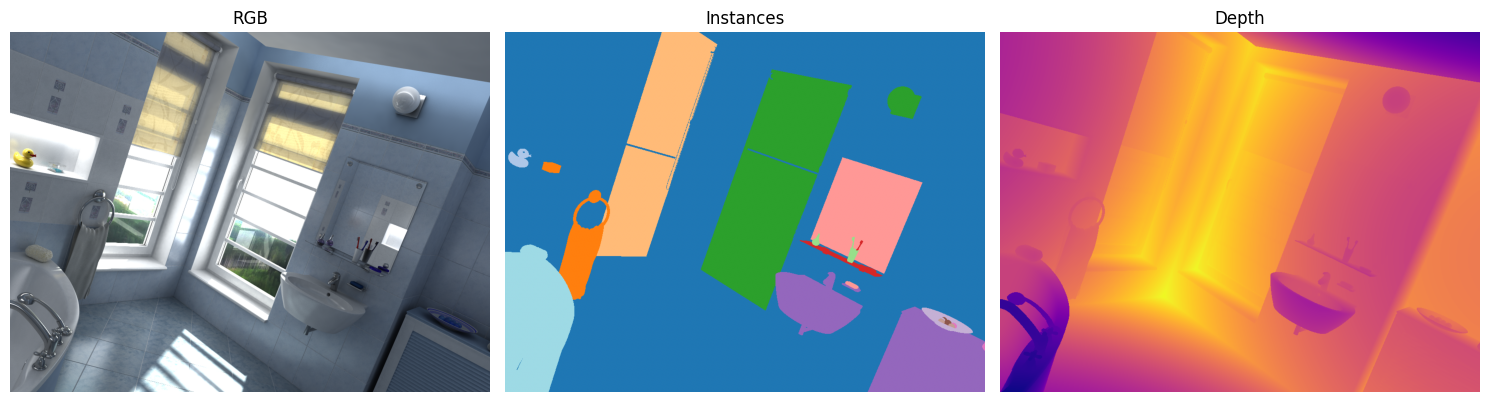

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

GEO_BASE = r'D:\Projects\Minor Project\Datasets\raw\ai_001_001\images\scene_cam_00_geometry_hdf5'
COLOR_BASE = r'D:\Projects\Minor Project\Datasets\raw\ai_001_001\images\scene_cam_00_final_hdf5'

# check instance file
inst_file = os.path.join(GEO_BASE, 'frame.0000.semantic_instance.hdf5')
with h5py.File(inst_file, 'r') as f:
    print(f"Keys: {list(f.keys())}")
    inst = np.array(f['dataset'])
    print(f"Instance shape: {inst.shape}, dtype: {inst.dtype}")
    u, c = np.unique(inst, return_counts=True)
    u, c = u[u > 0], c[u > 0]
    total = inst.shape[0] * inst.shape[1]
    print(f"Instances: {len(u)}")
    for uid, cnt in zip(u, c):
        print(f"  id={uid}: coverage={cnt/total:.3f}")

# check depth file
depth_files = [f for f in os.listdir(GEO_BASE) if 'depth' in f]
print(f"\nDepth files: {depth_files[:3]}")
with h5py.File(os.path.join(GEO_BASE, depth_files[0]), 'r') as f:
    depth = np.array(f['dataset'])
    print(f"Depth shape: {depth.shape}, range: {depth.min():.2f} - {depth.max():.2f}")

# visualize
color_file = os.path.join(COLOR_BASE, 'frame.0000.color.hdf5')
with h5py.File(color_file, 'r') as f:
    img = np.array(f['dataset'])
    img = (np.clip(img, 0, 1) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img);                        axes[0].set_title('RGB');      axes[0].axis('off')
axes[1].imshow(inst, cmap='tab20');         axes[1].set_title('Instances'); axes[1].axis('off')
axes[2].imshow(depth, cmap='plasma');       axes[2].set_title('Depth');    axes[2].axis('off')
plt.tight_layout()
plt.show()

In [3]:
# count frames
color_files = [f for f in os.listdir(COLOR_BASE) if f.endswith('color.hdf5')]
print(f"Frames in this scene: {len(color_files)}")

# check a few more frames for instance coverage
for fname in sorted(color_files)[:5]:
    frame_id = fname.split('.')[1]
    inst_path = os.path.join(GEO_BASE, f'frame.{frame_id}.semantic_instance.hdf5')
    with h5py.File(inst_path, 'r') as f:
        inst = np.array(f['dataset'])
    u, c = np.unique(inst, return_counts=True)
    u, c = u[u > 0], c[u > 0]
    total = inst.shape[0] * inst.shape[1]
    furniture = [(uid, cnt/total) for uid, cnt in zip(u, c) if 0.01 < cnt/total < 0.30]
    print(f"Frame {frame_id}: {len(u)} instances, {len(furniture)} furniture-sized")

Frames in this scene: 98
Frame 0000: 32 instances, 9 furniture-sized
Frame 0001: 23 instances, 8 furniture-sized
Frame 0002: 5 instances, 1 furniture-sized
Frame 0003: 19 instances, 4 furniture-sized
Frame 0004: 11 instances, 4 furniture-sized
